In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.distributions.multivariate_normal import MultivariateNormal
import matplotlib.pyplot as plt
import numpy as np

T=10
n=1000
N=100
dt = torch.tensor(T/n)

f= torch.tensor([1,0])
g= torch.eye(2)
mean = torch.zeros(2)
distrib1 = MultivariateNormal(mean,g)
sigma=0.1

Simulation of ODE vs. SDE

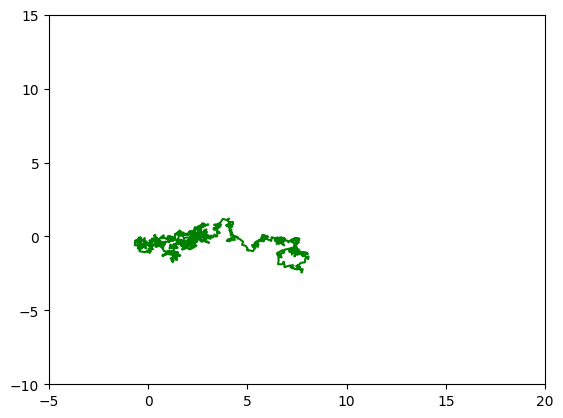

In [2]:
X = torch.zeros(n+1,2)
X[0,:] = np.sqrt(sigma)*distrib1.sample([1])

for i in range(n):
    #X[i+1,:] = X[i,:] + f*dt
    X[i+1,:] = X[i,:] + f*dt + distrib1.sample([1])@g*np.sqrt(dt)

plt.plot(X[:,0],X[:,1],'g-')
plt.xlim([-5, 20])
plt.ylim([-10, 15])
plt.show()


Forward and reverse simulation with particles

In [3]:
z = np.sqrt(sigma)*distrib1.rsample([N])
forward = torch.zeros(9,100,2)
forward[0] = z

# forward simulation of particles
for k in range(n):
    if (k+1) % 125 == 0:
        forward[(k+1)//125] = z
    z = z + dt*f + torch.sqrt(dt)*distrib1.rsample([N])

# reverse simulation of particles
# reverse 1 is incorrect time-reversal
# reverse 2 is correct time-reversal
x,y = z,z
reverse_1,reverse_2 = torch.zeros(9,100,2),torch.zeros(9,100,2)
reverse_1[0],reverse_2[0] = z,z

for k in range(n):
    if (k+1) %125 == 0:
        reverse_1[(k+1)//125] = x
        reverse_2[(k+1)//125] = y
    x = x - dt*f - torch.sqrt(dt)*distrib1.rsample([N])
    t = T-k*dt
    s = -(y-t*f)/(sigma+t)
    y = y - dt*(f - s) + torch.sqrt(dt)*distrib1.rsample([N])
    


Forward simulation

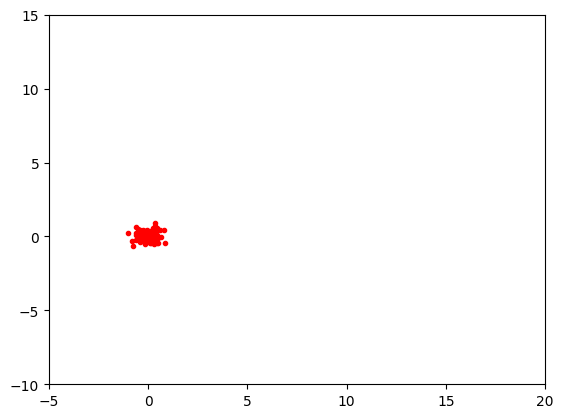

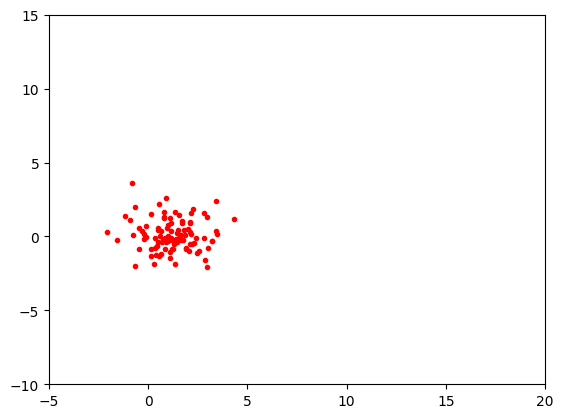

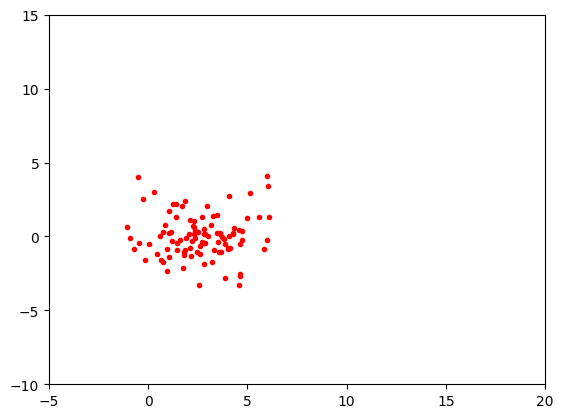

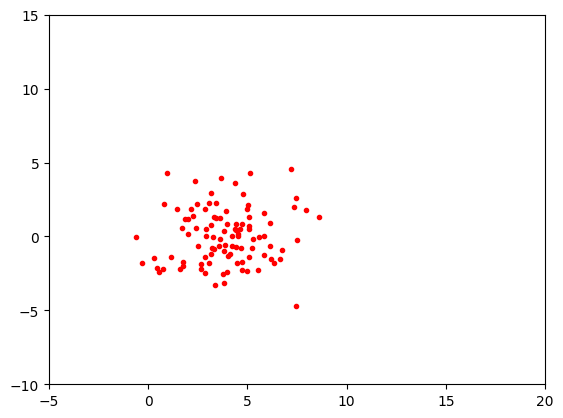

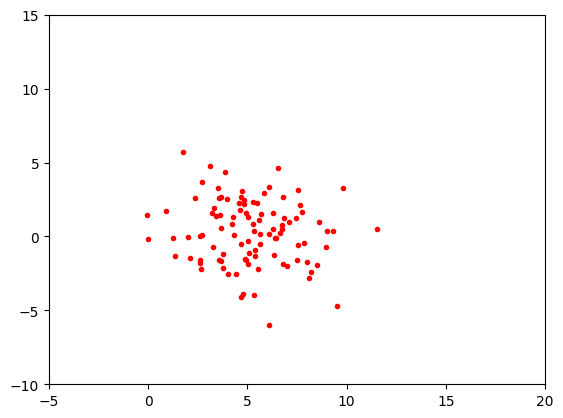

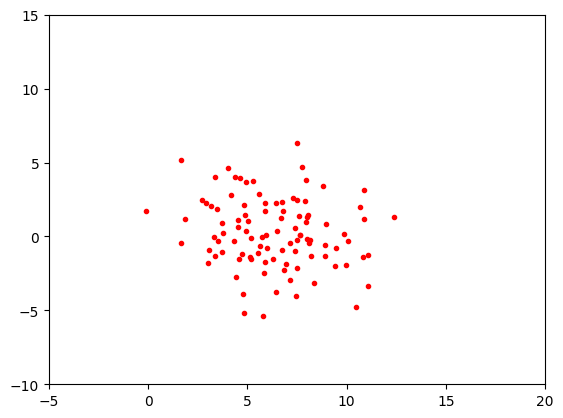

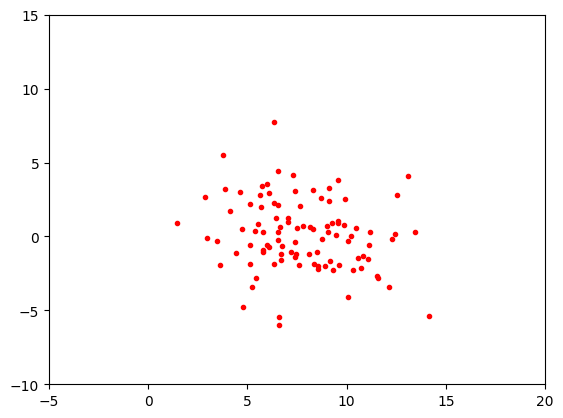

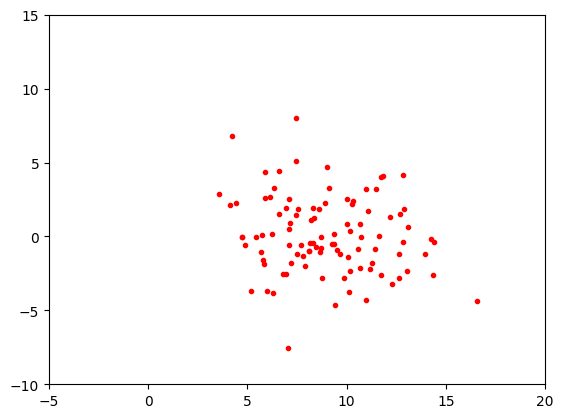

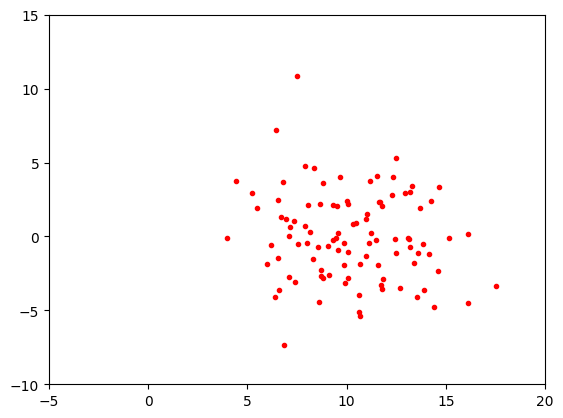

In [4]:
for i in range(9):
    plt.figure(i+1)
    plt.plot(forward[i,:,0],forward[i,:,1],'r.')
    plt.xlim([-5,20])
    plt.ylim([-10,15])
plt.show()

Reverse-time simulation (incorrect)

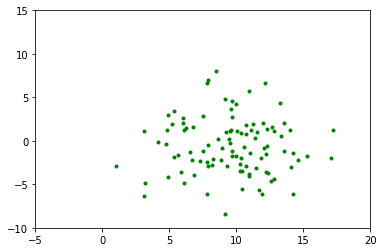

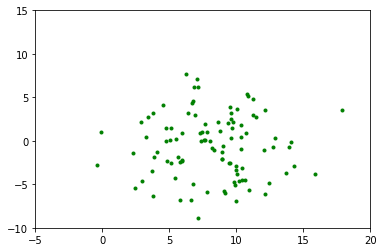

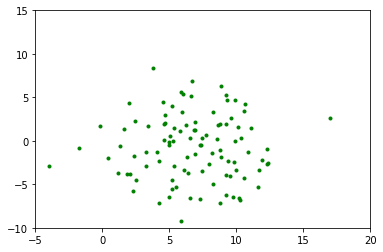

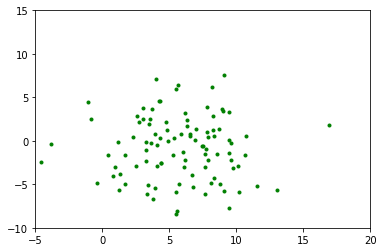

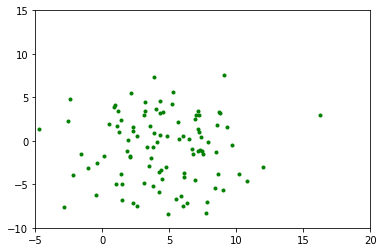

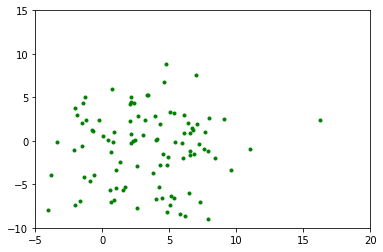

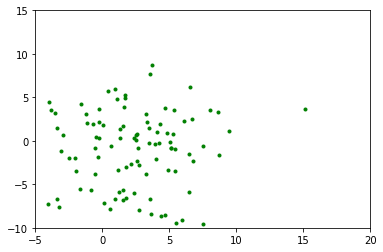

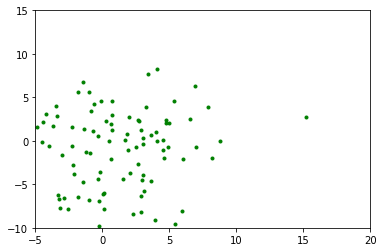

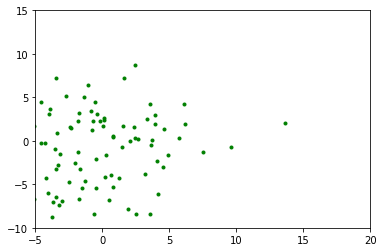

In [115]:
for i in range(9):
    plt.figure(i+1)
    plt.plot(reverse_1[i,:,0],reverse_1[i,:,1],'g.')
    plt.xlim([-5,20])
    plt.ylim([-10,15])
plt.show()

Reverse time simulation (correct)

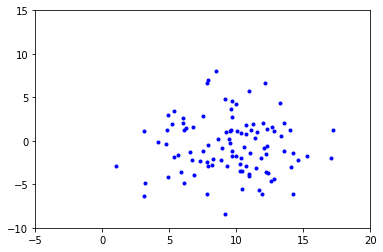

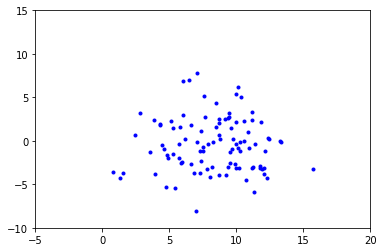

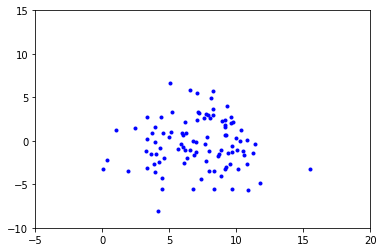

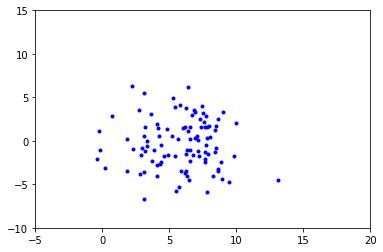

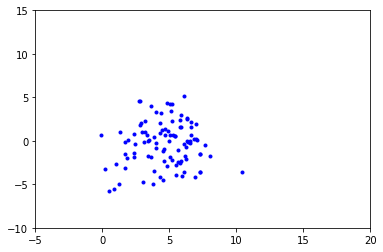

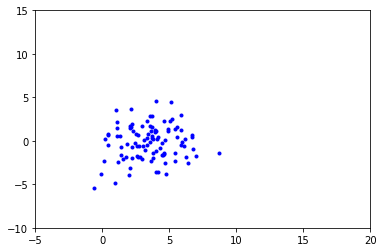

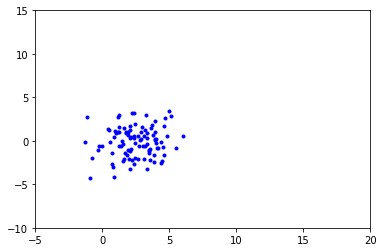

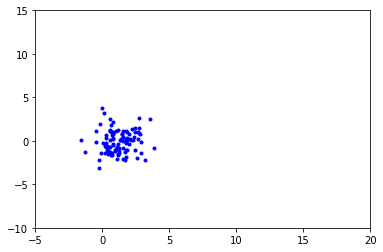

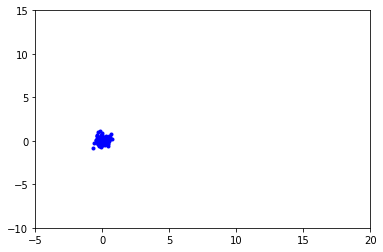

In [116]:
for i in range(9):
    plt.figure(i+1)
    plt.plot(reverse_2[i,:,0],reverse_2[i,:,1],'b.')
    plt.xlim([-5,20])
    plt.ylim([-10,15])
plt.show()